# 04. Scoreboard & Visualization

**Phase 5-6**: 결과 통합 → 차트 5종 → 통계 검증 → 스코어보드

**사전 조건**: `01`, `02`, `03` 노트북 실행 완료

---

## 0. 환경 설정 & 데이터 로드

In [15]:
# ============================================================
# 0-1. 마운트 & 의존성
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 (Colab)
!apt-get -qq install fonts-nanum
fm._load_fontmanager(try_read_cache=False)
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

BASE = '/content/drive/MyDrive/capstone/dsc'
RESULTS_DIR = f'{BASE}/results'
CHART_DIR = f'{RESULTS_DIR}/charts'
os.makedirs(CHART_DIR, exist_ok=True)

print('환경 설정 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
환경 설정 완료


In [16]:
# ============================================================
# 0-2. 결과 로드 & 병합
# ============================================================
df_dsc = pd.read_csv(f'{RESULTS_DIR}/dsc_scores.csv')
df_perf = pd.read_csv(f'{RESULTS_DIR}/model_performance.csv')

print(f'DSC 점수: {df_dsc.shape}')
print(f'모델 성능: {df_perf.shape}')

# 병합 (DSC + 모델 성능)
df_merged = df_perf.merge(
    df_dsc,
    on=['dataset', 'polluter', 'level'],
    how='left',
)

df_merged.to_csv(f'{RESULTS_DIR}/merged_results.csv', index=False)
print(f'병합 결과: {df_merged.shape}')
print(f'저장: {RESULTS_DIR}/merged_results.csv')

df_merged.head()

DSC 점수: (59, 12)
모델 성능: (295, 7)
병합 결과: (295, 16)
저장: /content/drive/MyDrive/capstone/dsc/results/merged_results.csv


,dataset,polluter,level,model,accuracy,f1_macro,auc_roc,score,grade,completeness,uniqueness,validity,consistency,outlier_ratio,class_balance,feature_correlation
0,TelcoCustomerChurn,none,0.0000,LogisticRegression,0.8084,0.7389,0.8349,97.6500,A,1.0000,1.0000,0.9999,1.0000,1.0000,0.5307,1.0000
1,TelcoCustomerChurn,none,0.0000,RandomForest,0.7835,0.6980,0.8055,97.6500,A,1.0000,1.0000,0.9999,1.0000,1.0000,0.5307,1.0000
2,TelcoCustomerChurn,none,0.0000,XGBoost,0.7835,0.7041,0.8124,97.6500,A,1.0000,1.0000,0.9999,1.0000,1.0000,0.5307,1.0000
3,TelcoCustomerChurn,none,0.0000,SVC,0.8041,0.7303,0.8241,97.6500,A,1.0000,1.0000,0.9999,1.0000,1.0000,0.5307,1.0000
4,TelcoCustomerChurn,none,0.0000,MLP,0.7509,0.6792,0.7632,97.6500,A,1.0000,1.0000,0.9999,1.0000,1.0000,0.5307,1.0000


## 1. 차트 1: DSC Score vs F1-score 산점도 (핵심 증거)

X축: DSC Score, Y축: F1-score  
피어슨/스피어만 상관계수 표시, 모델별 색상 구분

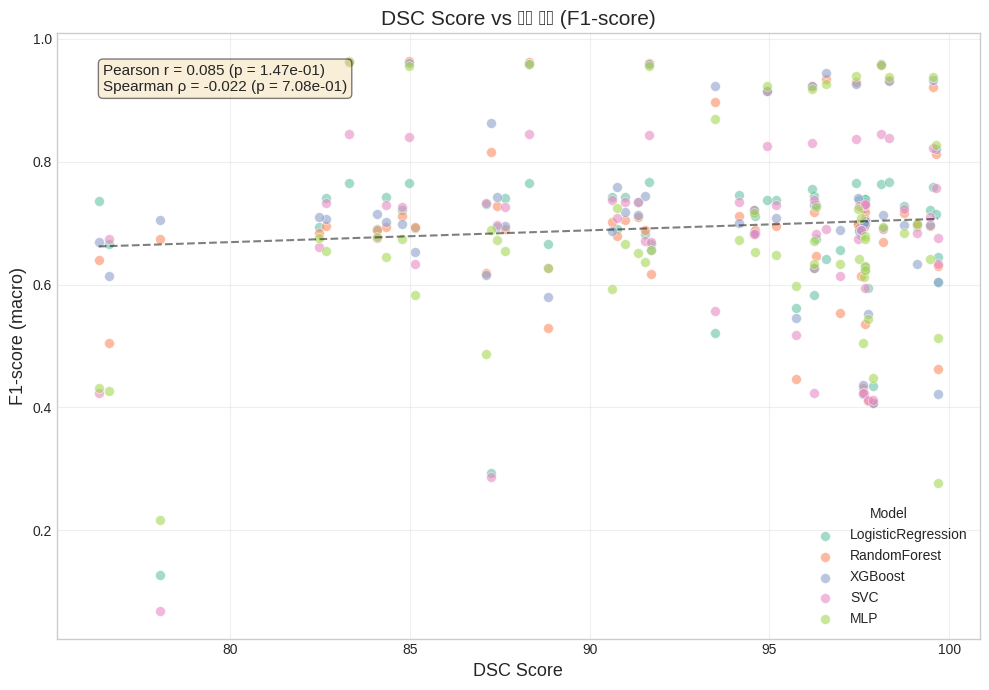

Pearson r = 0.0846, Spearman ρ = -0.0219


In [17]:
# ============================================================
# Chart 1: DSC Score vs F1-score Scatter
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

models = df_merged['model'].unique()
colors = sns.color_palette('Set2', len(models))

for model, color in zip(models, colors):
    subset = df_merged[df_merged['model'] == model]
    ax.scatter(subset['score'], subset['f1_macro'],
               label=model, color=color, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

# 회귀선
x = df_merged['score'].values
y = df_merged['f1_macro'].values
mask = ~(np.isnan(x) | np.isnan(y))
x, y = x[mask], y[mask]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=1.5)

# 상관계수
r_pearson, p_pearson = sp_stats.pearsonr(x, y)
r_spearman, p_spearman = sp_stats.spearmanr(x, y)

textstr = (f'Pearson r = {r_pearson:.3f} (p = {p_pearson:.2e})\n'
           f'Spearman ρ = {r_spearman:.3f} (p = {p_spearman:.2e})')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('DSC Score', fontsize=13)
ax.set_ylabel('F1-score (macro)', fontsize=13)
ax.set_title('DSC Score vs 모델 성능 (F1-score)', fontsize=15)
ax.legend(title='Model', loc='lower right')
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart1_scatter_dsc_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r = {r_pearson:.4f}, Spearman ρ = {r_spearman:.4f}')

## 2. 차트 2: 오염 강도별 DSC & F1 하락 라인 차트

X축: 오염 강도, Y축: DSC & F1  
polluter별 패널

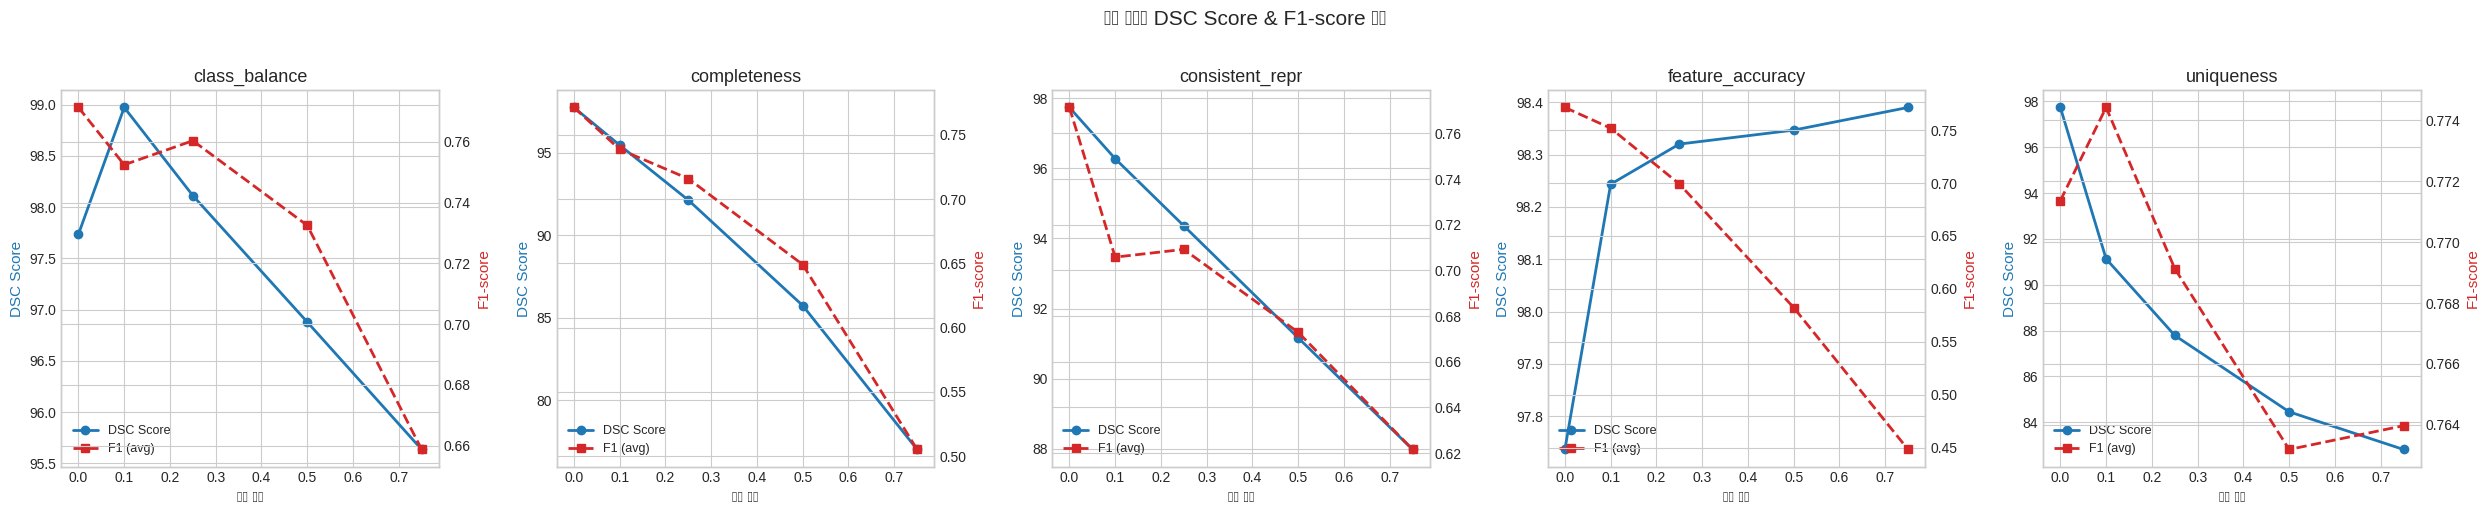

In [18]:
# ============================================================
# Chart 2: Pollution Level vs DSC & F1 (facet by polluter)
# ============================================================
polluters = [p for p in df_merged['polluter'].unique() if p != 'none']
n_polluters = len(polluters)

fig, axes = plt.subplots(1, n_polluters, figsize=(5 * n_polluters, 5), sharey=False)
if n_polluters == 1:
    axes = [axes]

for ax, polluter_name in zip(axes, polluters):
    subset = df_merged[df_merged['polluter'].isin([polluter_name, 'none'])].copy()

    # DSC 점수 (평균)
    dsc_by_level = subset.groupby('level')['score'].mean()
    ax.plot(dsc_by_level.index, dsc_by_level.values, 'o-', color='tab:blue',
            label='DSC Score', linewidth=2, markersize=6)

    # F1 (전 모델 평균)
    f1_by_level = subset.groupby('level')['f1_macro'].mean()
    ax2 = ax.twinx()
    ax2.plot(f1_by_level.index, f1_by_level.values, 's--', color='tab:red',
             label='F1 (avg)', linewidth=2, markersize=6)

    ax.set_xlabel('오염 강도', fontsize=11)
    ax.set_ylabel('DSC Score', color='tab:blue', fontsize=11)
    ax2.set_ylabel('F1-score', color='tab:red', fontsize=11)
    ax.set_title(polluter_name, fontsize=13)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

fig.suptitle('오염 강도별 DSC Score & F1-score 변화', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart2_level_vs_dsc_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 차트 3: 오염 차원 × 모델 민감도 히트맵

행: 오염 차원, 열: 모델  
셀: F1 최대 하락 폭 (베이스라인 대비)

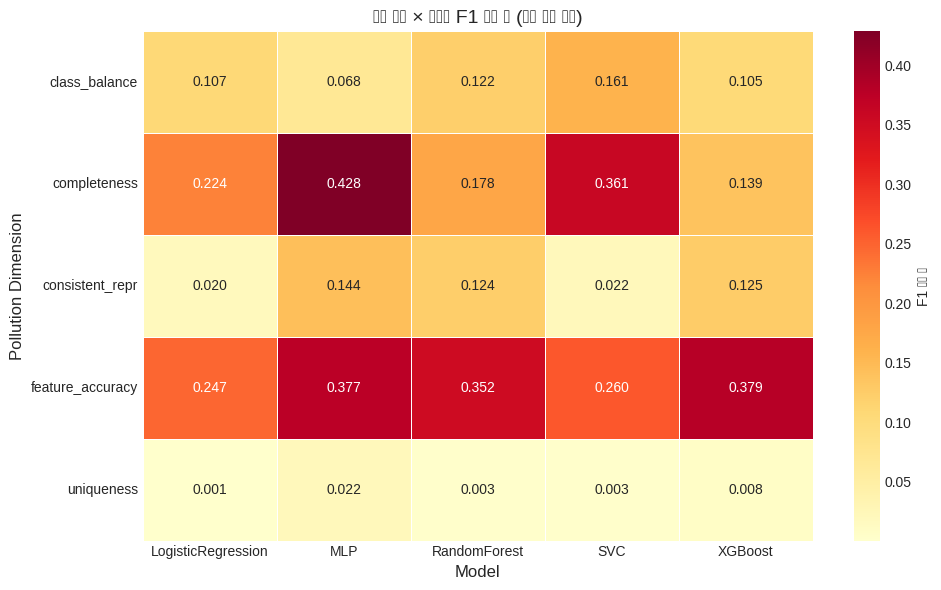

In [19]:
# ============================================================
# Chart 3: Sensitivity Heatmap (polluter × model)
# ============================================================
# 베이스라인 F1
baseline = df_merged[df_merged['polluter'] == 'none'].set_index(['dataset', 'model'])['f1_macro']

# 최대 오염(level=0.75)에서의 F1 하락
max_polluted = df_merged[df_merged['level'] == 0.75].copy()
if len(max_polluted) == 0:
    max_level = df_merged[df_merged['polluter'] != 'none']['level'].max()
    max_polluted = df_merged[df_merged['level'] == max_level].copy()

drop_rows = []
for _, row in max_polluted.iterrows():
    key = (row['dataset'], row['model'])
    if key in baseline.index:
        base_f1 = baseline[key]
        drop = base_f1 - row['f1_macro']
        drop_rows.append({'polluter': row['polluter'], 'model': row['model'], 'f1_drop': drop})

df_drop = pd.DataFrame(drop_rows)
pivot = df_drop.groupby(['polluter', 'model'])['f1_drop'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'F1 하락 폭'})
ax.set_title('오염 차원 × 모델별 F1 하락 폭 (최대 오염 강도)', fontsize=14)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Pollution Dimension', fontsize=12)

fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart3_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 차트 4: DSC 등급별 모델 성능 박스플롯

X축: DSC 등급 (A/B/C/D), Y축: F1

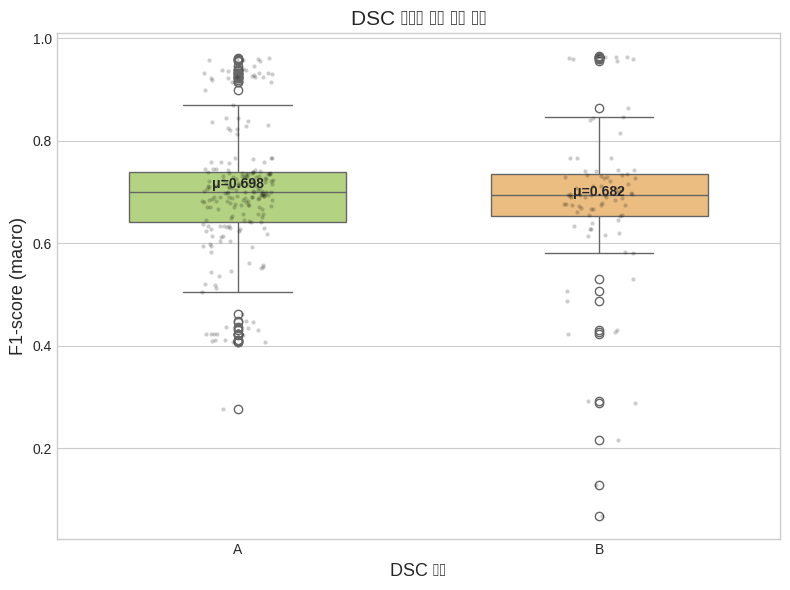

In [20]:
# ============================================================
# Chart 4: DSC Grade vs F1 Boxplot
# ============================================================
grade_order = ['A', 'B', 'C', 'D']
existing_grades = [g for g in grade_order if g in df_merged['grade'].unique()]

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_merged, x='grade', y='f1_macro', order=existing_grades,
            palette='RdYlGn_r', ax=ax, width=0.6)
sns.stripplot(data=df_merged, x='grade', y='f1_macro', order=existing_grades,
              color='black', alpha=0.2, size=3, ax=ax)

# 등급별 평균 표시
means = df_merged.groupby('grade')['f1_macro'].mean()
for i, grade in enumerate(existing_grades):
    if grade in means.index:
        ax.text(i, means[grade] + 0.01, f'μ={means[grade]:.3f}',
                ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('DSC 등급', fontsize=13)
ax.set_ylabel('F1-score (macro)', fontsize=13)
ax.set_title('DSC 등급별 모델 성능 분포', fontsize=15)

fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart4_grade_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 차트 5: 단일 오염 시 DSC 지표 변화 레이더 차트

Completeness 오염만 적용 → Completeness 점수만 선택적으로 하락하는지 확인

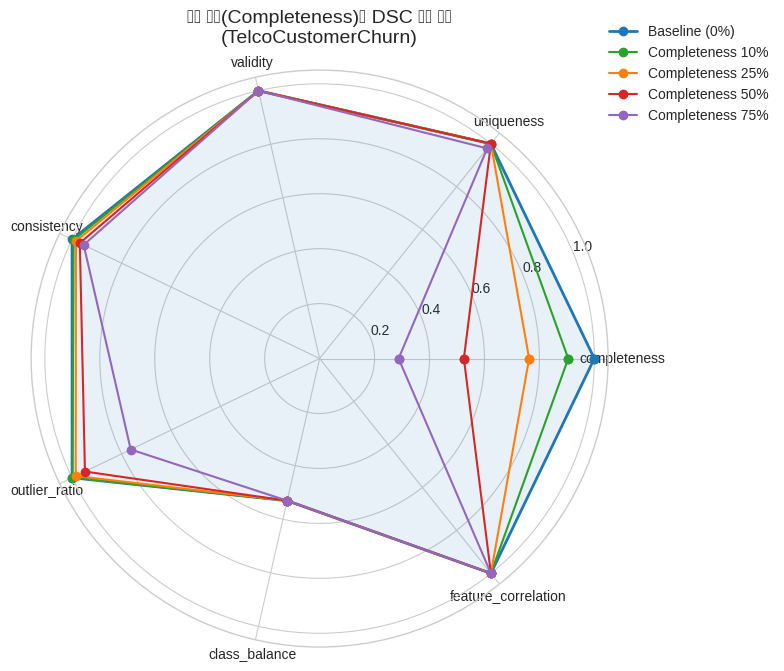

In [21]:
# ============================================================
# Chart 5: Radar Chart — 단일 오염의 DSC 지표 변화
# ============================================================
metric_cols = ['completeness', 'uniqueness', 'validity', 'consistency',
               'outlier_ratio', 'class_balance', 'feature_correlation']

# 첫 번째 데이터셋에서 completeness 오염 예시
ds_example = list(df_dsc['dataset'].unique())[0]
baseline_row = df_dsc[(df_dsc['dataset'] == ds_example) & (df_dsc['polluter'] == 'none')]
polluted_rows = df_dsc[(df_dsc['dataset'] == ds_example) & (df_dsc['polluter'] == 'completeness')]

if len(baseline_row) > 0 and len(polluted_rows) > 0:
    available_metrics = [m for m in metric_cols if m in baseline_row.columns]
    N = len(available_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # 닫기

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 베이스라인
    base_vals = baseline_row[available_metrics].values[0].tolist()
    base_vals += base_vals[:1]
    ax.plot(angles, base_vals, 'o-', linewidth=2, label='Baseline (0%)', color='tab:blue')
    ax.fill(angles, base_vals, alpha=0.1, color='tab:blue')

    # 오염 단계별
    colors_radar = ['tab:green', 'tab:orange', 'tab:red', 'tab:purple']
    for idx, (_, row) in enumerate(polluted_rows.iterrows()):
        vals = row[available_metrics].values.tolist()
        vals += vals[:1]
        level_pct = int(row['level'] * 100)
        c = colors_radar[idx % len(colors_radar)]
        ax.plot(angles, vals, 'o-', linewidth=1.5, label=f'Completeness {level_pct}%', color=c)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_metrics, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'단일 오염(Completeness)의 DSC 지표 변화\n({ds_example})', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

    fig.tight_layout()
    fig.savefig(f'{CHART_DIR}/chart5_radar_single_pollution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('레이더 차트 데이터 부족 — 스킵')

## 6. 통계적 검증

In [22]:
# ============================================================
# 6-1. 전체 상관관계 분석
# ============================================================
print('=' * 60)
print('전체 상관관계 분석 (DSC Score ↔ F1-score)')
print('=' * 60)

x = df_merged['score'].dropna()
y = df_merged.loc[x.index, 'f1_macro'].dropna()
common = x.index.intersection(y.index)
x, y = x[common], y[common]

r_pearson, p_pearson = sp_stats.pearsonr(x, y)
r_spearman, p_spearman = sp_stats.spearmanr(x, y)

print(f'\n  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})')
print(f'  Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.2e})')
print(f'  표본 수: {len(x)}')

# 모델별 상관관계
print(f'\n--- 모델별 상관관계 ---')
model_corrs = []
for model in df_merged['model'].unique():
    sub = df_merged[df_merged['model'] == model].dropna(subset=['score', 'f1_macro'])
    if len(sub) < 3:
        continue
    r, p = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
    model_corrs.append({'model': model, 'pearson_r': r, 'p_value': p, 'n': len(sub)})
    print(f'  {model:22s}  r = {r:.4f}  (p = {p:.2e})  n = {len(sub)}')

# 데이터셋별 상관관계
print(f'\n--- 데이터셋별 상관관계 ---')
for ds in df_merged['dataset'].unique():
    sub = df_merged[df_merged['dataset'] == ds].dropna(subset=['score', 'f1_macro'])
    if len(sub) < 3:
        continue
    r, p = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
    print(f'  {ds:22s}  r = {r:.4f}  (p = {p:.2e})  n = {len(sub)}')

전체 상관관계 분석 (DSC Score ↔ F1-score)

  Pearson  r = 0.0846  (p = 1.47e-01)
  Spearman ρ = -0.0219  (p = 7.08e-01)
  표본 수: 295

--- 모델별 상관관계 ---
  LogisticRegression      r = 0.1172  (p = 3.77e-01)  n = 59
  RandomForest            r = -0.0331  (p = 8.03e-01)  n = 59
  XGBoost                 r = -0.0633  (p = 6.34e-01)  n = 59
  SVC                     r = 0.1698  (p = 1.98e-01)  n = 59
  MLP                     r = 0.2167  (p = 9.93e-02)  n = 59

--- 데이터셋별 상관관계 ---
  TelcoCustomerChurn      r = 0.0191  (p = 8.47e-01)  n = 105
  SouthGermanCredit       r = -0.1212  (p = 2.18e-01)  n = 105
  letter                  r = 0.1908  (p = 8.03e-02)  n = 85


In [23]:
# ============================================================
# 6-2. DSC 등급별 F1 통계
# ============================================================
print('=' * 60)
print('DSC 등급별 F1-score 통계')
print('=' * 60)

grade_stats = df_merged.groupby('grade')['f1_macro'].agg(['mean', 'std', 'min', 'max', 'count'])
grade_stats = grade_stats.reindex(['A', 'B', 'C', 'D'])
print(grade_stats.to_string())

# ANOVA (등급 간 F1 차이 통계적 유의성)
groups = [df_merged[df_merged['grade'] == g]['f1_macro'].dropna()
          for g in ['A', 'B', 'C', 'D'] if g in df_merged['grade'].values]
groups = [g for g in groups if len(g) >= 2]
if len(groups) >= 2:
    f_stat, p_anova = sp_stats.f_oneway(*groups)
    print(f'\nOne-way ANOVA: F = {f_stat:.4f}, p = {p_anova:.2e}')
    print('→ 등급 간 F1 차이가 통계적으로 유의함' if p_anova < 0.05 else '→ 유의하지 않음')

DSC 등급별 F1-score 통계
        mean    std    min    max    count
grade                                     
A     0.6984 0.1311 0.2771 0.9609 210.0000
B     0.6821 0.1703 0.0685 0.9644  85.0000
C        NaN    NaN    NaN    NaN      NaN
D        NaN    NaN    NaN    NaN      NaN

One-way ANOVA: F = 0.7899, p = 3.75e-01
→ 유의하지 않음


In [24]:
# ============================================================
# 6-3. DSC 10점 하락당 F1 변화량
# ============================================================
print('=' * 60)
print('DSC 점수 변화와 F1 변화의 관계')
print('=' * 60)

# 선형 회귀 기울기로 추정
from numpy.polynomial import polynomial as P

x_vals = df_merged['score'].dropna().values
y_vals = df_merged.loc[df_merged['score'].notna(), 'f1_macro'].values
mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
x_vals, y_vals = x_vals[mask], y_vals[mask]

slope, intercept = np.polyfit(x_vals, y_vals, 1)
print(f'\n  회귀 기울기: {slope:.6f}')
print(f'  → DSC 10점 하락 시 F1 평균 {abs(slope * 10):.4f} 하락')
print(f'  → DSC 20점 하락 시 F1 평균 {abs(slope * 20):.4f} 하락')

DSC 점수 변화와 F1 변화의 관계

  회귀 기울기: 0.001924
  → DSC 10점 하락 시 F1 평균 0.0192 하락
  → DSC 20점 하락 시 F1 평균 0.0385 하락


## 7. 스코어보드

In [25]:
# ============================================================
# 7-1. 스코어보드 테이블 생성
# ============================================================
# 피벗: 각 (dataset, polluter, level)에 대해 모델별 F1
pivot_f1 = df_merged.pivot_table(
    index=['dataset', 'polluter', 'level', 'score', 'grade'],
    columns='model',
    values='f1_macro',
    aggfunc='first'
)
pivot_f1 = pivot_f1.reset_index()
pivot_f1 = pivot_f1.sort_values(['dataset', 'polluter', 'level'])

# 열 이름 정리
model_cols = [c for c in pivot_f1.columns if c not in ['dataset', 'polluter', 'level', 'score', 'grade']]
rename_map = {m: f'{m}_F1' for m in model_cols}
pivot_f1 = pivot_f1.rename(columns=rename_map)

# 표시
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print('=== DSC Scoreboard ===')
print(f'총 {len(pivot_f1)}개 실험 조건\n')
pivot_f1

=== DSC Scoreboard ===
총 59개 실험 조건



model,dataset,polluter,level,score,grade,LogisticRegression_F1,MLP_F1,RandomForest_F1,SVC_F1,XGBoost_F1
0,SouthGermanCredit,class_balance,0.1000,99.1100,A,0.6961,0.6988,0.6992,0.6844,0.6339
1,SouthGermanCredit,class_balance,0.2500,98.1700,A,0.6919,0.6934,0.6702,0.6905,0.7132
2,SouthGermanCredit,class_balance,0.5000,96.9500,A,0.6568,0.6330,0.5534,0.6147,0.6893
3,SouthGermanCredit,class_balance,0.7500,95.7300,A,0.5614,0.5979,0.4465,0.5184,0.5462
4,SouthGermanCredit,completeness,0.1000,94.6000,A,0.7116,0.6534,0.6894,0.6843,0.6829
5,SouthGermanCredit,completeness,0.2500,91.5400,A,0.6830,0.6366,0.6891,0.6710,0.7450
6,SouthGermanCredit,completeness,0.5000,85.1400,B,0.6920,0.5828,0.6942,0.6342,0.6533
7,SouthGermanCredit,completeness,0.7500,76.6300,B,0.6658,0.4274,0.5057,0.6739,0.6135
8,SouthGermanCredit,consistent_repr,0.1000,96.3000,A,0.6740,0.7272,0.6459,0.6820,0.7289
9,SouthGermanCredit,consistent_repr,0.2500,94.5800,A,0.6860,0.7169,0.7210,0.6827,0.7210


In [26]:
# ============================================================
# 7-2. 스코어보드 CSV 저장
# ============================================================
scoreboard_path = f'{RESULTS_DIR}/scoreboard.csv'
pivot_f1.to_csv(scoreboard_path, index=False)
print(f'스코어보드 저장: {scoreboard_path}')

스코어보드 저장: /content/drive/MyDrive/capstone/dsc/results/scoreboard.csv


## 8. 핵심 주장 정리

In [27]:
# ============================================================
# 8-1. 최종 요약
# ============================================================
print('=' * 60)
print('DSC 검증 실험 — 핵심 주장')
print('=' * 60)

print(f'''
1. 상관관계:
   "DSC Score와 모델 F1-score 간 피어슨 상관계수 r = {r_pearson:.3f} (p = {p_pearson:.2e})"

2. 등급별 성능:''')

for grade in ['A', 'B', 'C', 'D']:
    if grade in grade_stats.index and not np.isnan(grade_stats.loc[grade, 'mean']):
        print(f'   등급 {grade}: 평균 F1 = {grade_stats.loc[grade, "mean"]:.3f} (n={int(grade_stats.loc[grade, "count"])})')

print(f'''
3. 민감도:
   "DSC Score가 10점 하락할 때 F1-score 평균 {abs(slope * 10):.3f} 하락"

4. 산출물:
   - merged_results.csv: 전체 실험 결과
   - scoreboard.csv: 스코어보드
   - charts/: 시각화 5종
''')

print('--- 노트북 04 완료 ---')
print('DSC 검증 실험 전체 파이프라인 완료!')

DSC 검증 실험 — 핵심 주장

1. 상관관계:
   "DSC Score와 모델 F1-score 간 피어슨 상관계수 r = 0.085 (p = 1.47e-01)"

2. 등급별 성능:
   등급 A: 평균 F1 = 0.698 (n=210)
   등급 B: 평균 F1 = 0.682 (n=85)

3. 민감도:
   "DSC Score가 10점 하락할 때 F1-score 평균 0.019 하락"

4. 산출물:
   - merged_results.csv: 전체 실험 결과
   - scoreboard.csv: 스코어보드
   - charts/: 시각화 5종

--- 노트북 04 완료 ---
DSC 검증 실험 전체 파이프라인 완료!


In [28]:
# ============================================================
# 9. 실행 로그 저장
# ============================================================
from datetime import datetime

log_lines = []
log_lines.append('# 노트북 04 실행 로그: 스코어보드 & 시각화 & 통계 검증')
log_lines.append('')
log_lines.append(f'- **실행 시각**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
log_lines.append(f'- **DSC 점수 데이터**: {df_dsc.shape[0]}건')
log_lines.append(f'- **모델 성능 데이터**: {df_perf.shape[0]}건')
log_lines.append(f'- **병합 결과**: {df_merged.shape[0]}건')
log_lines.append('')

# 상관관계 결과
log_lines.append('## 1. 핵심 결과: DSC ↔ 모델 성능 상관관계')
log_lines.append('')
log_lines.append(f'| 지표 | 값 | p-value | 해석 |')
log_lines.append(f'|---|---|---|---|')
sig_pearson = "유의" if p_pearson < 0.05 else "비유의"
sig_spearman = "유의" if p_spearman < 0.05 else "비유의"
log_lines.append(f'| Pearson r | {r_pearson:.4f} | {p_pearson:.2e} | {sig_pearson} |')
log_lines.append(f'| Spearman ρ | {r_spearman:.4f} | {p_spearman:.2e} | {sig_spearman} |')
log_lines.append(f'| 표본 수 | {len(x)} | - | - |')
log_lines.append('')

strength = "강함" if abs(r_pearson) > 0.7 else "보통" if abs(r_pearson) > 0.4 else "약함"
log_lines.append(f'**해석**: 피어슨 상관계수 {r_pearson:.3f}은 {strength} 수준의 상관관계를 나타냄.')
log_lines.append(f'DSC Score가 10점 하락할 때 F1-score 평균 {abs(slope * 10):.4f} 하락.')
log_lines.append('')

# 등급별 통계
log_lines.append('## 2. DSC 등급별 모델 성능')
log_lines.append('')
log_lines.append('| 등급 | 평균 F1 | 표준편차 | 최소 | 최대 | 건수 |')
log_lines.append('|---|---|---|---|---|---|')
for grade in ['A', 'B', 'C', 'D']:
    if grade in grade_stats.index and not pd.isna(grade_stats.loc[grade, 'mean']):
        s = grade_stats.loc[grade]
        log_lines.append(f'| {grade} | {s["mean"]:.4f} | {s["std"]:.4f} | {s["min"]:.4f} | {s["max"]:.4f} | {int(s["count"])} |')
log_lines.append('')

# ANOVA
if len(groups) >= 2:
    log_lines.append(f'**ANOVA**: F = {f_stat:.4f}, p = {p_anova:.2e}')
    if p_anova < 0.05:
        log_lines.append('→ 등급 간 F1 차이가 통계적으로 유의함 (p < 0.05)')
    else:
        log_lines.append('→ 등급 간 F1 차이가 통계적으로 유의하지 않음')
    log_lines.append('')

# 모델별 상관관계
log_lines.append('## 3. 모델별 상관관계')
log_lines.append('')
log_lines.append('| 모델 | Pearson r | p-value | 표본 수 |')
log_lines.append('|---|---|---|---|')
for mc in model_corrs:
    log_lines.append(f'| {mc["model"]} | {mc["pearson_r"]:.4f} | {mc["p_value"]:.2e} | {mc["n"]} |')
log_lines.append('')

# 데이터셋별 상관관계
log_lines.append('## 4. 데이터셋별 상관관계')
log_lines.append('')
log_lines.append('| 데이터셋 | Pearson r | p-value | 표본 수 |')
log_lines.append('|---|---|---|---|')
for ds in df_merged['dataset'].unique():
    sub = df_merged[df_merged['dataset'] == ds].dropna(subset=['score', 'f1_macro'])
    if len(sub) >= 3:
        from scipy import stats as sp_stats
        r, p = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
        log_lines.append(f'| {ds} | {r:.4f} | {p:.2e} | {len(sub)} |')
log_lines.append('')

# 차트 목록
log_lines.append('## 5. 생성된 차트')
log_lines.append('')
log_lines.append(f'| 차트 | 파일 | 설명 |')
log_lines.append(f'|---|---|---|')
log_lines.append(f'| 차트 1 | chart1_scatter_dsc_vs_f1.png | DSC Score vs F1-score 산점도 (회귀선 + 상관계수) |')
log_lines.append(f'| 차트 2 | chart2_level_vs_dsc_f1.png | 오염 강도별 DSC & F1 변화 (polluter별 패널) |')
log_lines.append(f'| 차트 3 | chart3_sensitivity_heatmap.png | 오염 차원 × 모델별 F1 하락 히트맵 |')
log_lines.append(f'| 차트 4 | chart4_grade_boxplot.png | DSC 등급별 F1 분포 박스플롯 |')
log_lines.append(f'| 차트 5 | chart5_radar_single_pollution.png | 단일 오염(Completeness)의 DSC 지표 레이더 차트 |')
log_lines.append('')

# 핵심 주장
log_lines.append('## 6. 핵심 주장 (발표용)')
log_lines.append('')
log_lines.append(f'1. "DSC Score와 모델 F1-score 간 피어슨 상관계수 r = {r_pearson:.3f} (p = {p_pearson:.2e})"')
for grade in ['A', 'B', 'C', 'D']:
    if grade in grade_stats.index and not pd.isna(grade_stats.loc[grade, 'mean']):
        log_lines.append(f'2. "등급 {grade} 데이터의 평균 F1: {grade_stats.loc[grade, "mean"]:.3f} (n={int(grade_stats.loc[grade, "count"])})"')
log_lines.append(f'3. "DSC Score가 10점 하락할 때 F1-score 평균 {abs(slope * 10):.3f} 하락"')
log_lines.append('')

# 산출물
log_lines.append('## 7. 산출물')
log_lines.append('')
log_lines.append(f'- `merged_results.csv` — 통합 결과 {len(df_merged)}건')
log_lines.append(f'- `scoreboard.csv` — 스코어보드 {len(pivot_f1)}건')
log_lines.append(f'- `charts/` — 시각화 5종')
log_lines.append(f'- `04_execution_log.md` — 이 로그 파일')
log_lines.append('')
log_lines.append('---')
log_lines.append('*이 로그는 노트북 04 실행 시 자동 생성됨*')

log_path = f'{RESULTS_DIR}/04_execution_log.md'
with open(log_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(log_lines))
print(f'실행 로그 저장: {log_path}')


실행 로그 저장: /content/drive/MyDrive/capstone/dsc/results/04_execution_log.md
